# 02 Exploratory Data Analysis
Perform initial data exploration and visual checks.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / "data" / "processed"

In [2]:
orders = pd.read_parquet(PROCESSED_DIR / "olist_orders_clean.parquet")
items = pd.read_parquet(PROCESSED_DIR / "olist_order_items_clean.parquet")
payments = pd.read_parquet(PROCESSED_DIR / "olist_order_payments_clean.parquet")
reviews = pd.read_parquet(PROCESSED_DIR / "olist_order_reviews_clean.parquet")

print("orders", orders.shape)
print("items", items.shape)
print("payments", payments.shape)
print("reviews", reviews.shape)

orders (99441, 9)
items (112650, 11)
payments (103886, 7)
reviews (98410, 8)


,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


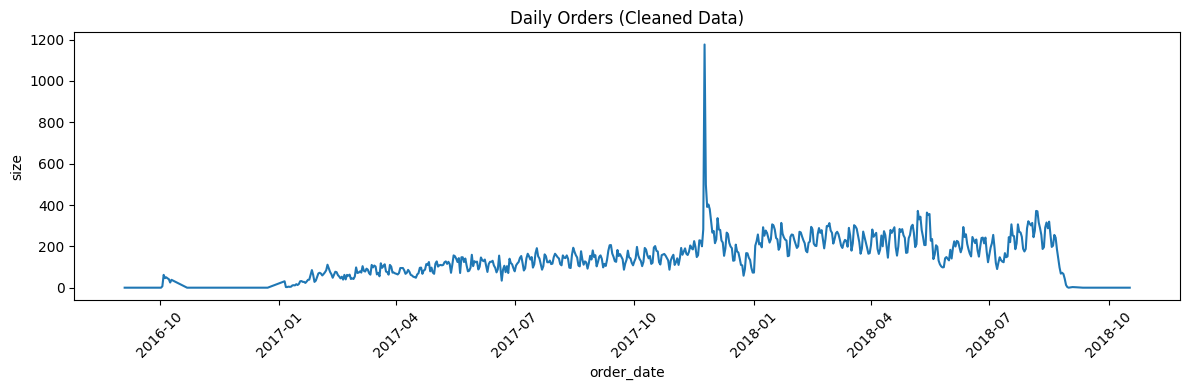

In [3]:
orders_by_status = orders["order_status"].value_counts(dropna=False).rename_axis("order_status").reset_index(name="count")
display(orders_by_status)

daily_orders = (
    orders.dropna(subset=["order_purchase_timestamp"])
    .assign(order_date=lambda d: d["order_purchase_timestamp"].dt.date)
    .groupby("order_date", as_index=False)
    .size()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_orders, x="order_date", y="size")
plt.title("Daily Orders (Cleaned Data)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()